In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

In [4]:
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('csv/dataset.csv')
df

,region,health_ratio,ratio_underage_partic,num_of_diplomas_on_100k,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
0,Белгородская область,9.350000,0.243133,0.673333,0.3770,61.690957,93.291799,5613.166667,1719.000000,932.333333,36.000000,150.666667,63.7190,1.529301e+06,14502.2
1,Брянская область,8.200000,0.325733,0.380000,0.3704,63.158787,91.566055,6419.833333,2317.666667,1244.666667,21.833333,162.333333,55.5290,1.166264e+06,13860.6
2,Владимирская область,9.600000,0.396267,0.483333,0.3380,59.172750,90.118338,6128.333333,2229.333333,1053.833333,21.166667,211.833333,56.3495,1.342524e+06,15843.0
3,Воронежская область,11.200000,0.391767,0.516667,0.3936,60.338851,91.618336,9996.000000,2800.000000,1660.500000,140.166667,336.500000,66.5920,2.303798e+06,26951.0
4,Ивановская область,9.533333,0.500083,0.786667,0.3616,60.597528,90.745768,4691.000000,1881.000000,883.333333,18.666667,190.833333,55.6130,9.287970e+05,11731.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Амурская область,3.816667,0.847283,0.238333,0.3988,51.812441,84.395681,6586.000000,2410.333333,1155.166667,61.666667,322.333333,46.8515,7.657652e+05,15200.0
81,Магаданская область,3.900000,0.828967,NaN,0.4056,57.418410,78.269071,1221.166667,410.666667,233.500000,9.833333,52.166667,49.2455,1.360392e+05,2449.6
82,Сахалинская область,7.350000,0.826383,0.558333,0.4098,55.630337,80.719409,4016.000000,1488.666667,658.666667,67.500000,169.666667,54.5830,4.656602e+05,8440.8
83,Еврейская автономная область,9.683333,0.968167,NaN,0.3364,52.460141,72.858529,1421.500000,437.166667,312.666667,3.166667,73.666667,37.5105,1.502248e+05,2910.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   region                      85 non-null     object 
 1   health_ratio                85 non-null     float64
 2   ratio_underage_partic       85 non-null     float64
 3   num_of_diplomas_on_100k     80 non-null     float64
 4   coeff_Gini                  85 non-null     float64
 5   not_smoking_male%           85 non-null     float64
 6   not_smoking_female%         85 non-null     float64
 7   num_of_criminals            85 non-null     float64
 8   num_of_alcohol_crimes       85 non-null     float64
 9   num_of_female_crimes        85 non-null     float64
 10  num_of_drugs_crimes         85 non-null     float64
 11  num_of_underaged_criminals  85 non-null     float64
 12  life_quality                85 non-null     float64
 13  population_size             85 non-nu

In [7]:
df.describe()

,health_ratio,ratio_underage_partic,num_of_diplomas_on_100k,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
count,85.000000,85.000000,80.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,8.500000e+01,85.000000
mean,9.626471,0.479004,1.068396,0.371113,62.519186,89.347115,8533.654902,2720.725490,1492.615686,82.658824,300.711765,56.361065,1.729390e+06,21784.962353
std,4.864638,0.229090,1.426258,0.024774,6.857531,5.336671,7015.133870,2100.040155,1234.315953,110.283722,241.707786,10.331159,1.885626e+06,20744.741366
min,1.483333,0.003583,0.036667,0.330800,51.812441,72.858529,362.333333,107.833333,68.166667,0.666667,4.166667,30.582000,4.168667e+04,780.800000
25%,6.800000,0.322350,0.477083,0.354000,58.769229,86.153759,3948.500000,1278.500000,654.166667,21.833333,136.500000,49.912000,6.865120e+05,8748.400000
50%,8.566667,0.448250,0.666667,0.367200,60.940828,90.070037,6258.000000,2169.500000,1119.333333,44.333333,222.666667,55.613000,1.140389e+06,14126.400000
75%,11.016667,0.613983,1.019583,0.386000,63.660051,92.431741,10946.333333,3781.333333,1793.500000,91.166667,407.000000,63.476500,2.166836e+06,26951.000000
max,29.783333,1.053050,10.015000,0.455000,95.568405,100.000000,35716.000000,8864.000000,6523.000000,684.833333,1077.333333,84.272000,1.303065e+07,133515.800000


In [11]:
distribution_df = pd.DataFrame([[df[col].skew() for col in df.columns[1:]], [df[col].kurt() for col in df.columns[1:]]], columns=df.columns[1:], index=['skewness', 'kurtosis'])
distribution_df

,health_ratio,ratio_underage_partic,num_of_diplomas_on_100k,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
skewness,1.883936,0.462869,3.997231,0.865507,2.403458,-0.360288,1.687274,1.202342,1.708212,3.190036,1.316142,0.289755,3.441347,2.492052
kurtosis,5.027831,-0.299486,20.336929,1.016869,8.527802,0.480609,3.134341,0.995278,3.313149,12.648530,1.427901,0.594846,16.276397,9.346602


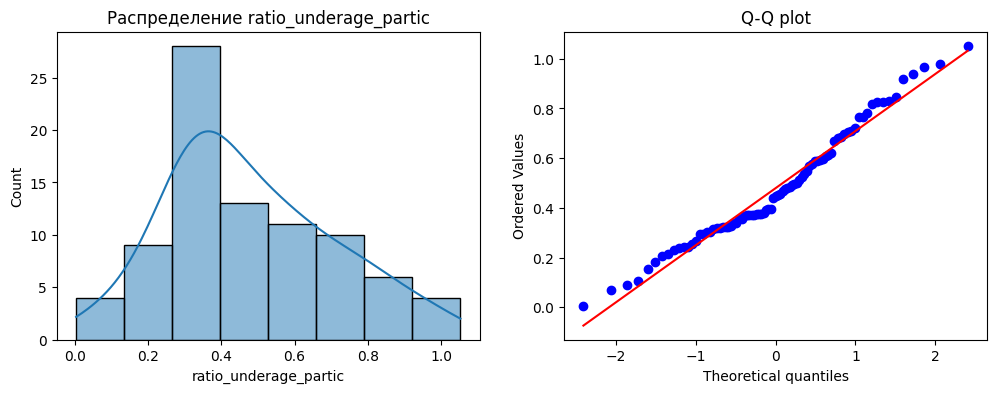

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['ratio_underage_partic'], kde=True)
plt.title('Распределение ratio_underage_partic')
plt.subplot(1, 2, 2)
stats.probplot(df['ratio_underage_partic'], dist="norm", plot=plt)
plt.title('Q-Q plot')
plt.show()

In [24]:
shapiro_test = stats.shapiro(df['ratio_underage_partic'])
pd.DataFrame(shapiro_test, columns = ['value'], index = ['Shapiro_Wilk_statistic', 'p-value'])

,value
Shapiro_Wilk_statistic,0.971601
p-value,0.057389


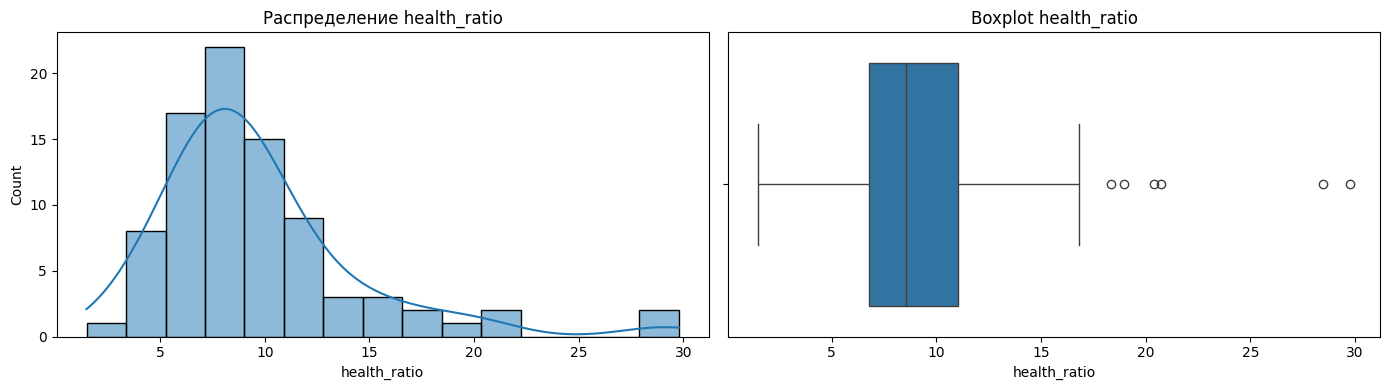

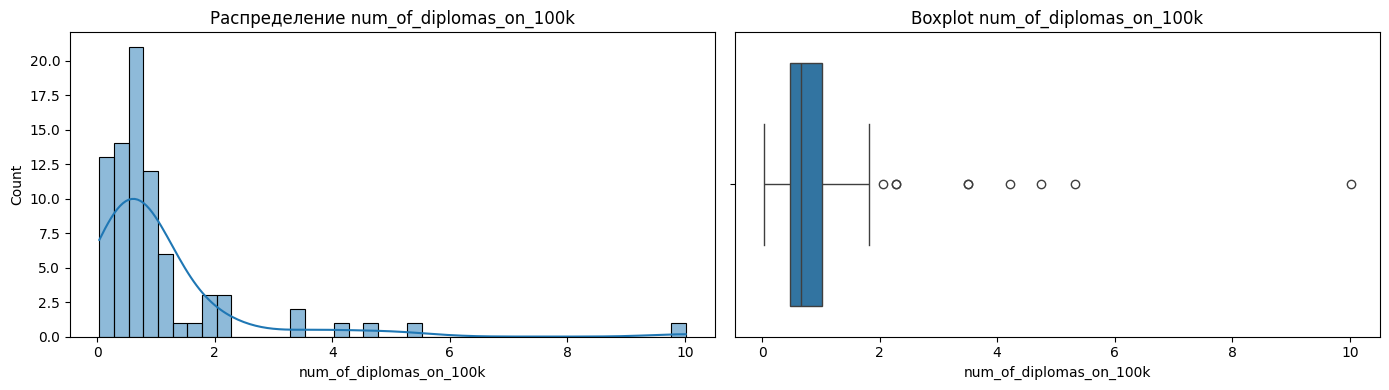

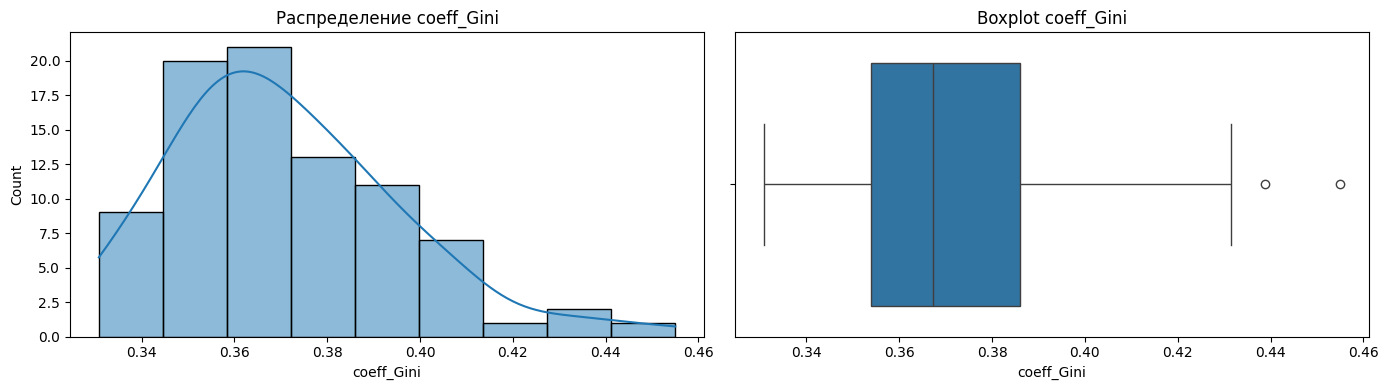

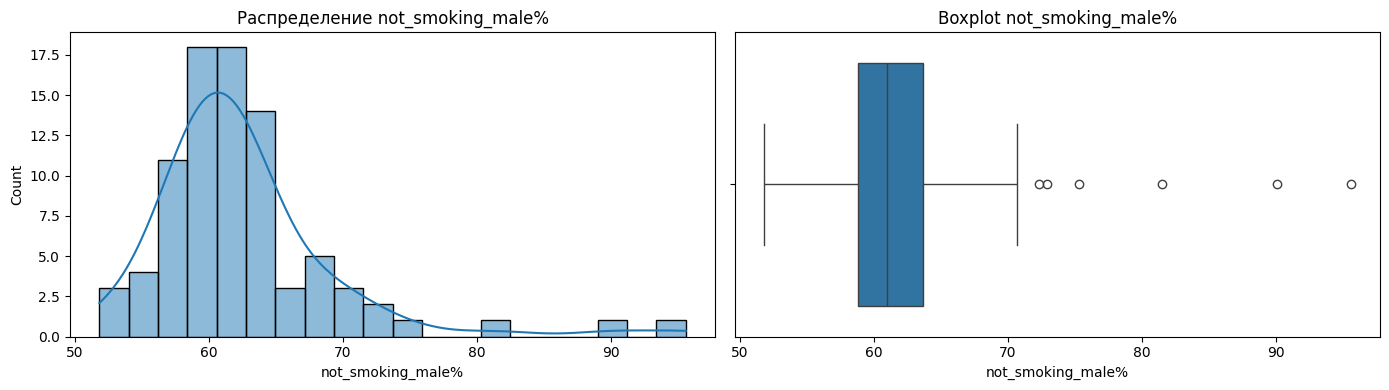

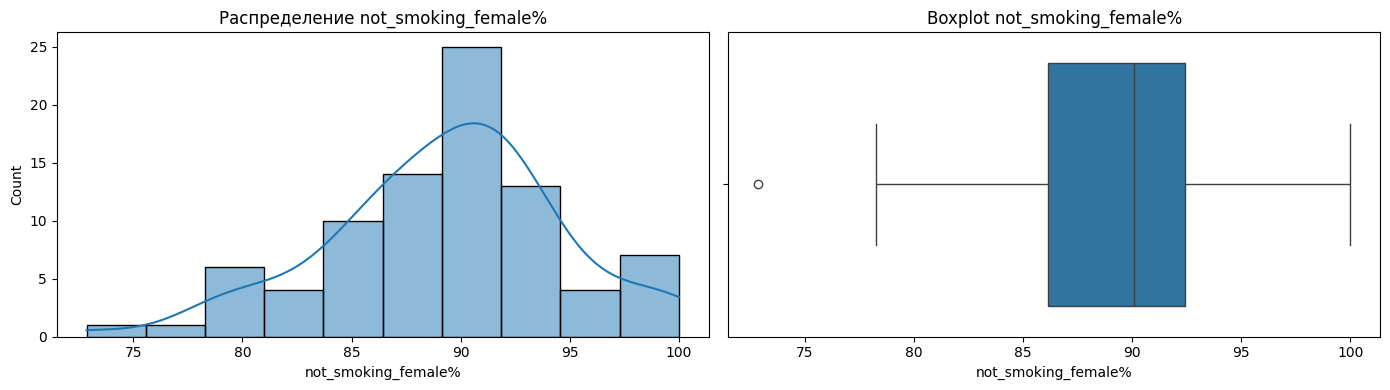

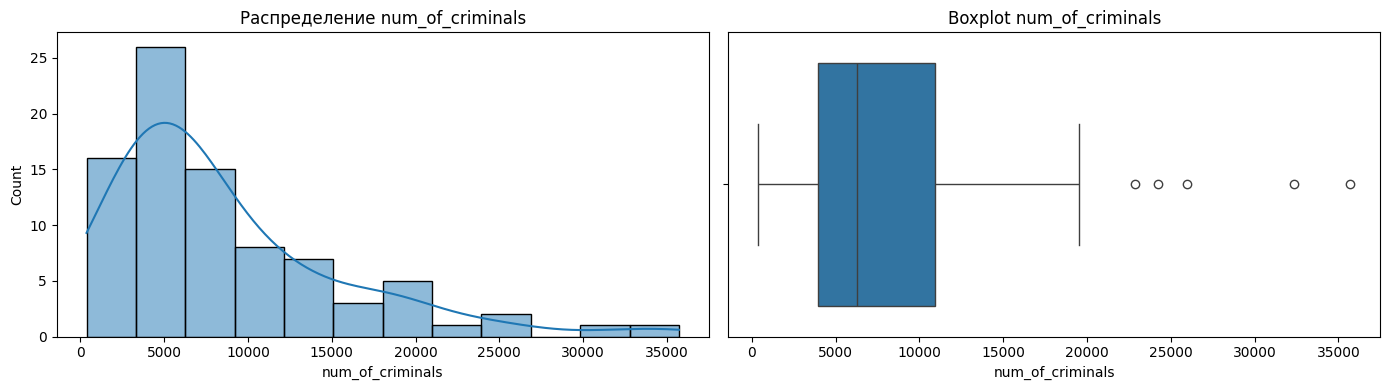

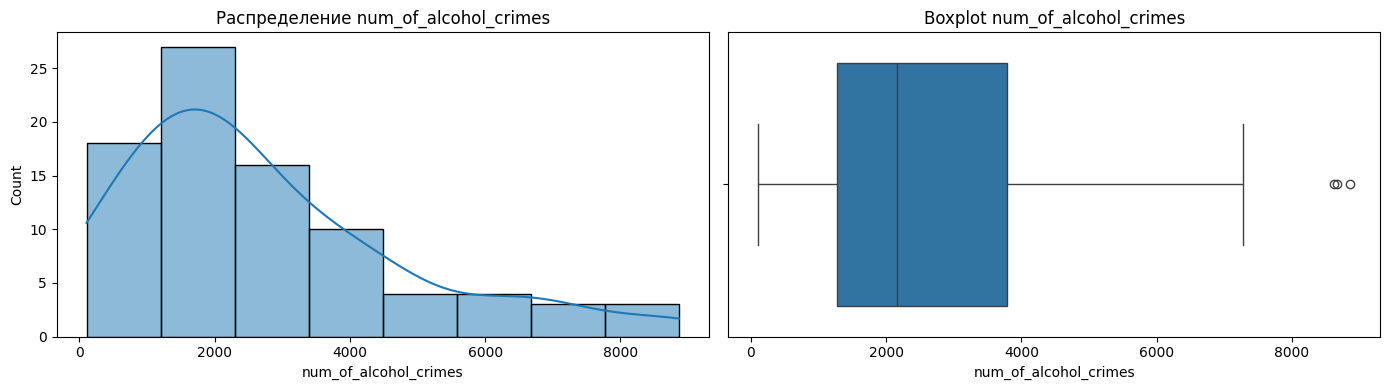

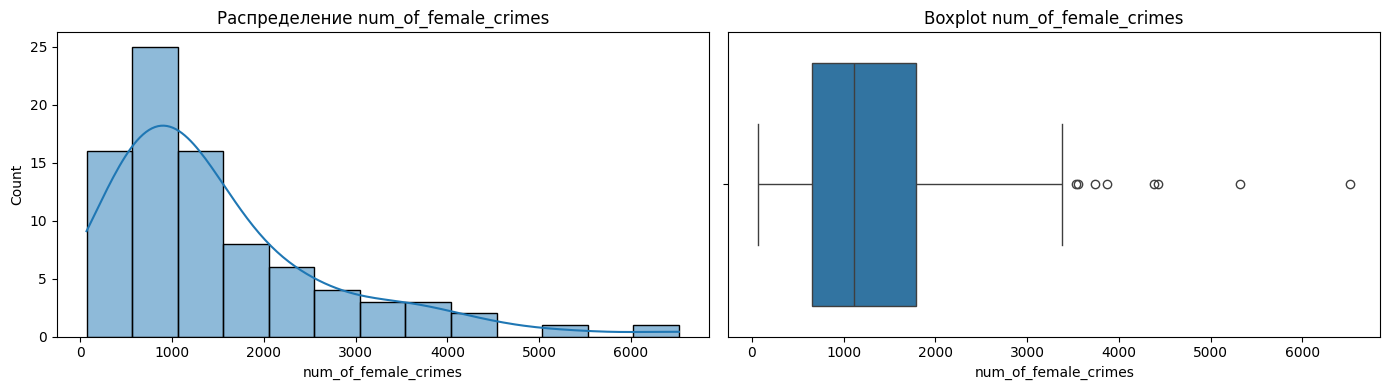

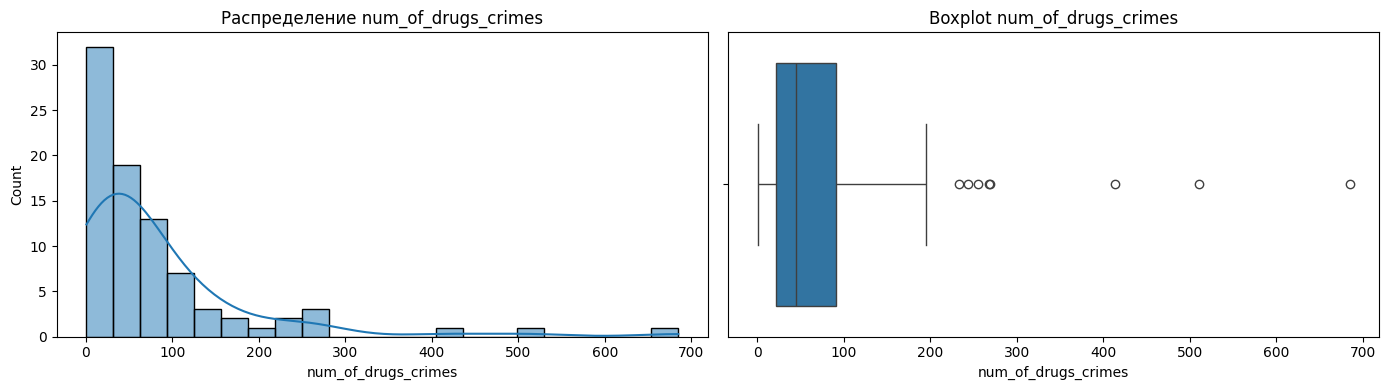

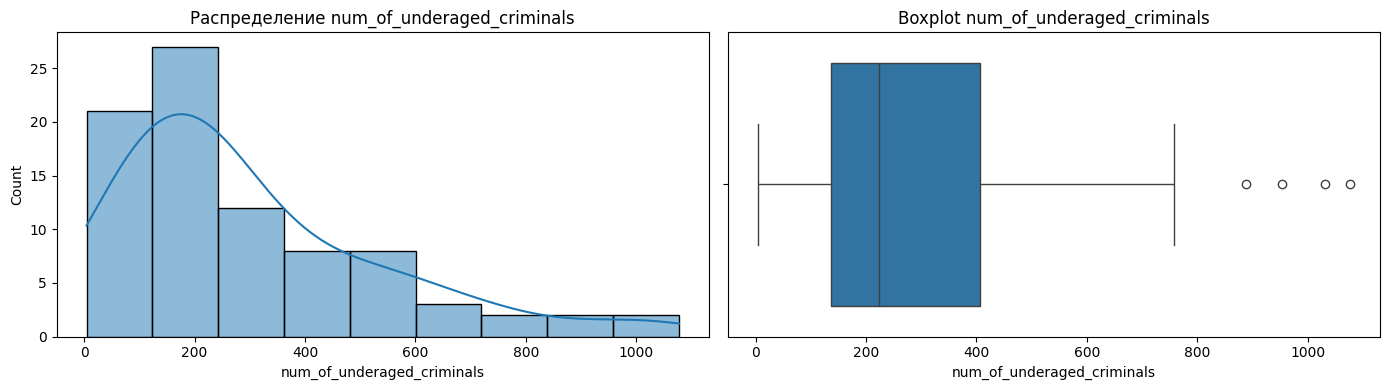

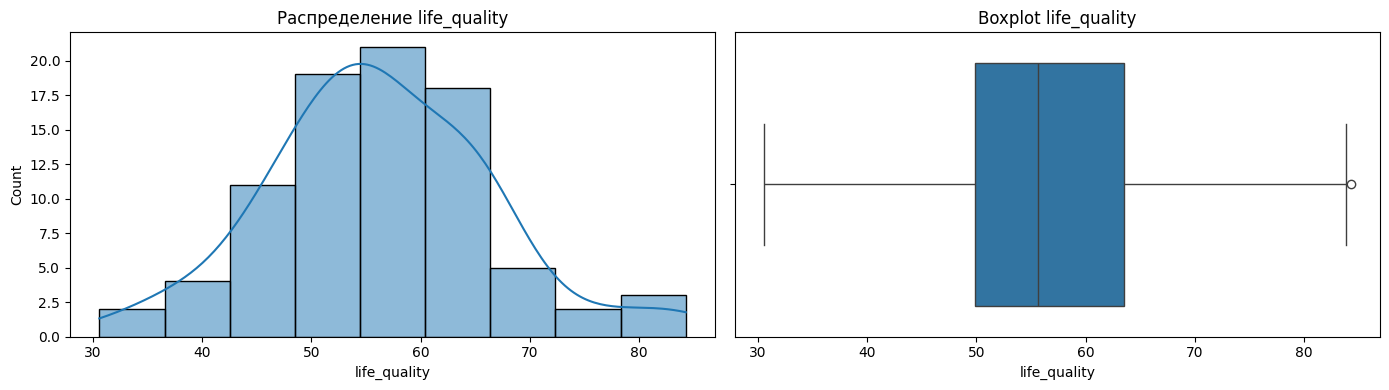

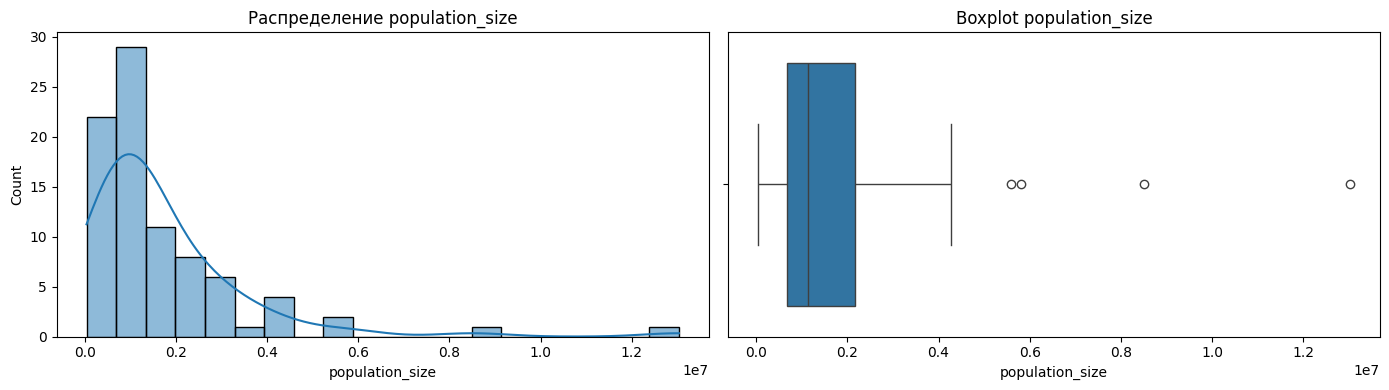

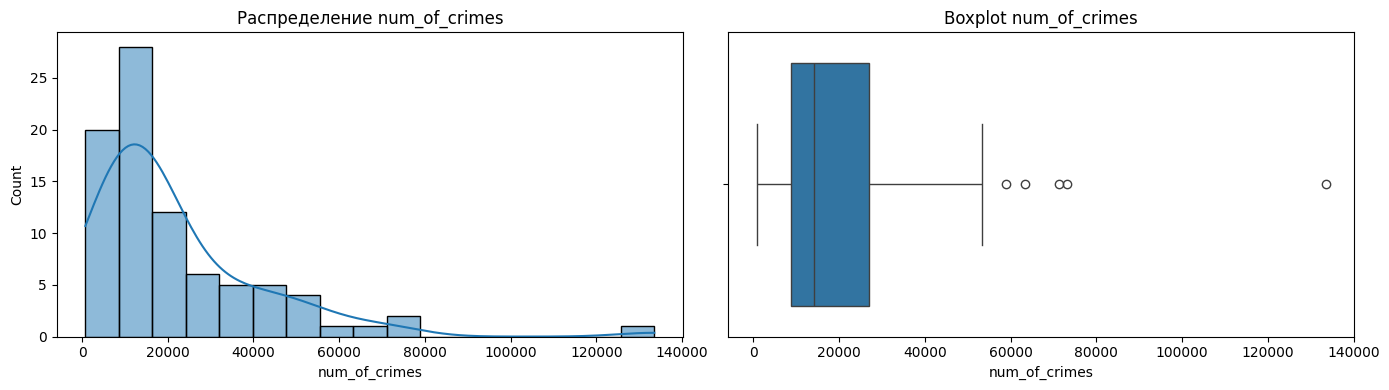

In [20]:
for col in df.columns[1:]:
    if col == 'ratio_underage_partic':
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение {col}')

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot {col}')
    plt.tight_layout()

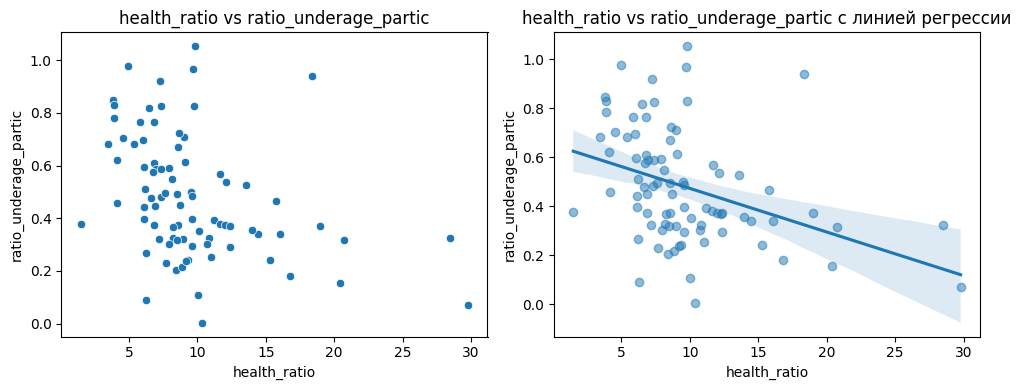

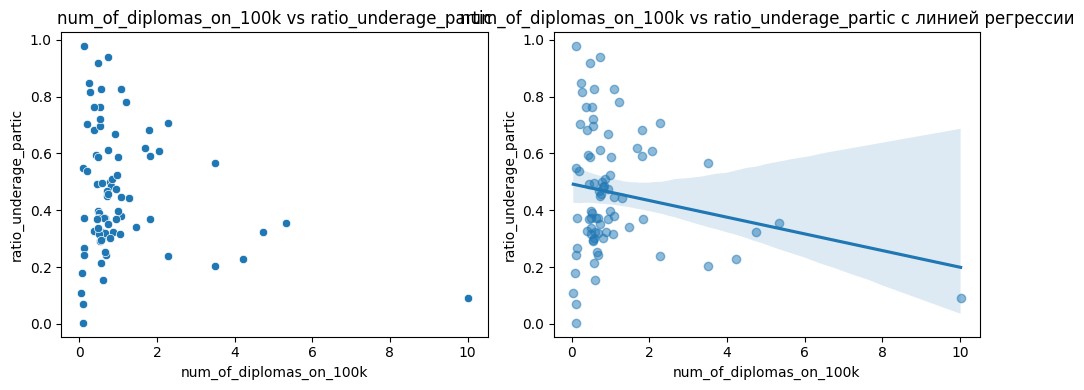

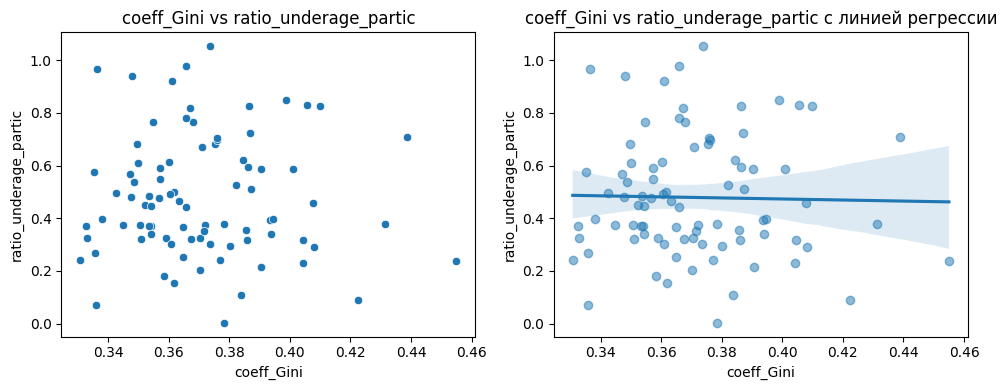

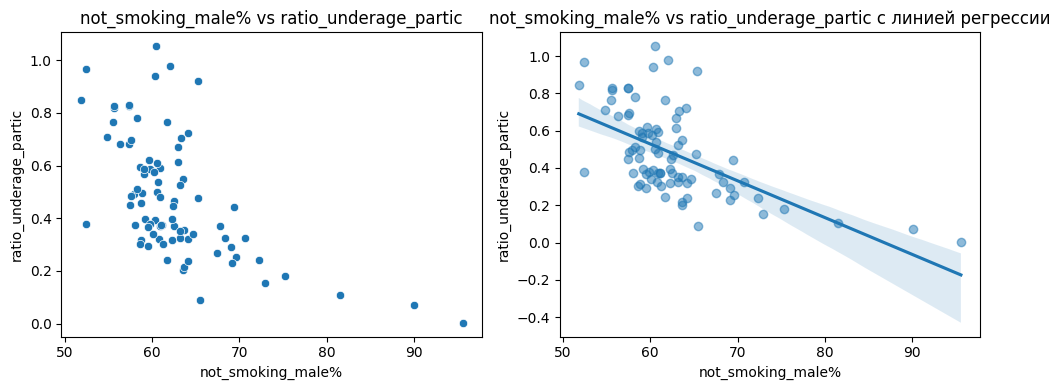

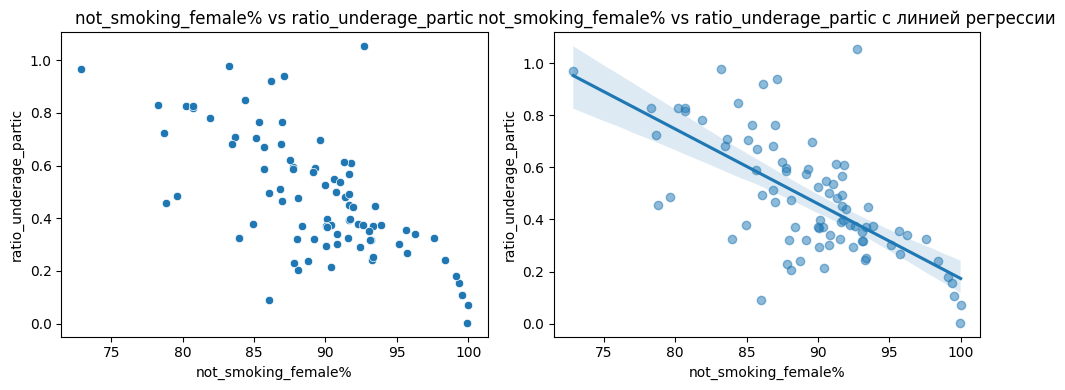

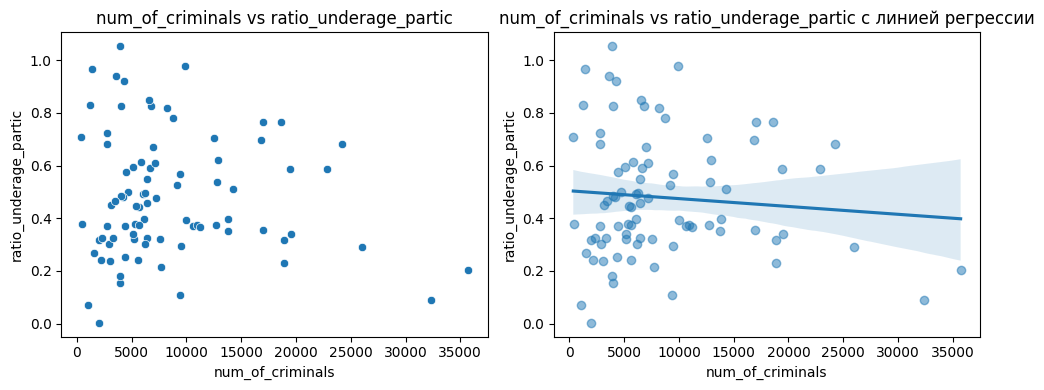

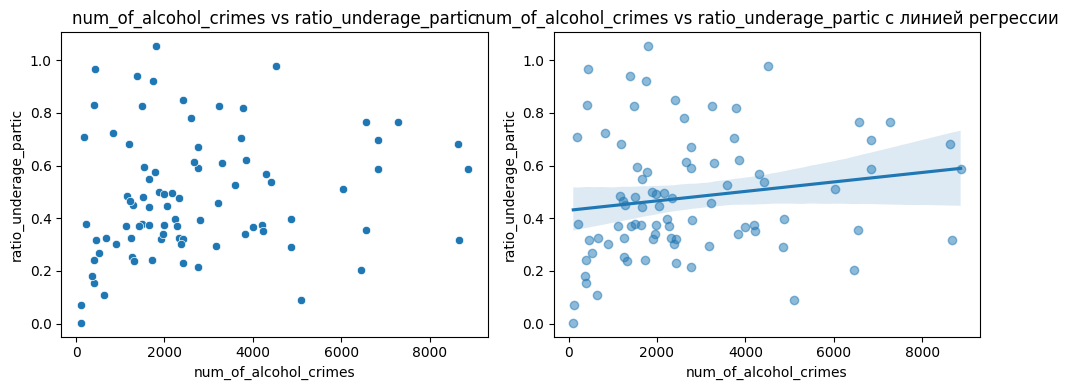

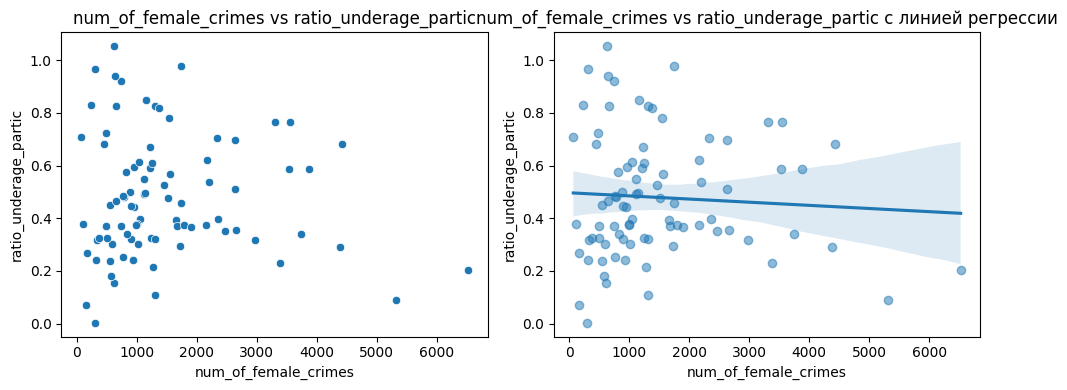

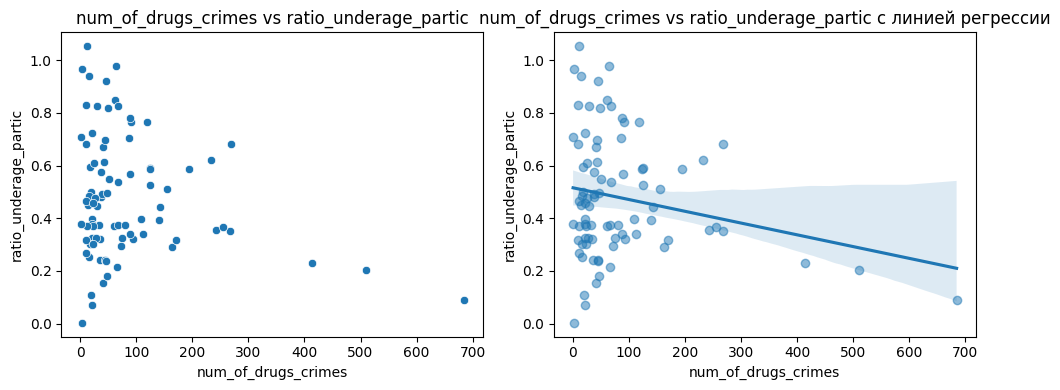

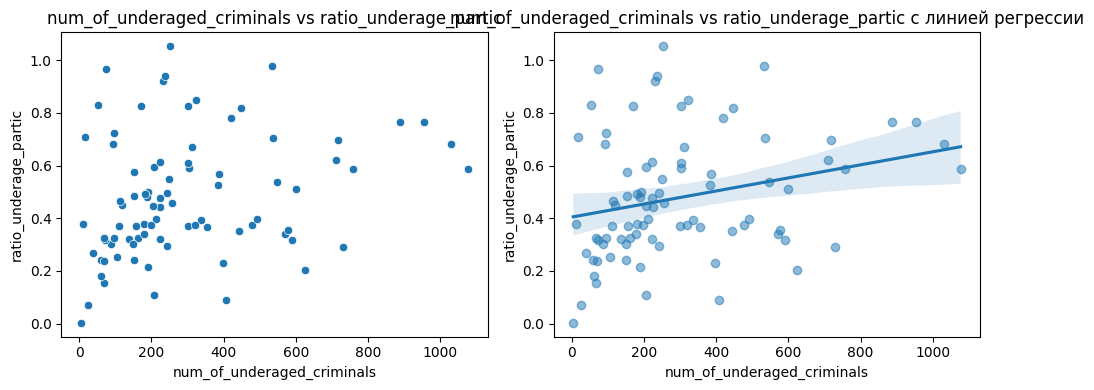

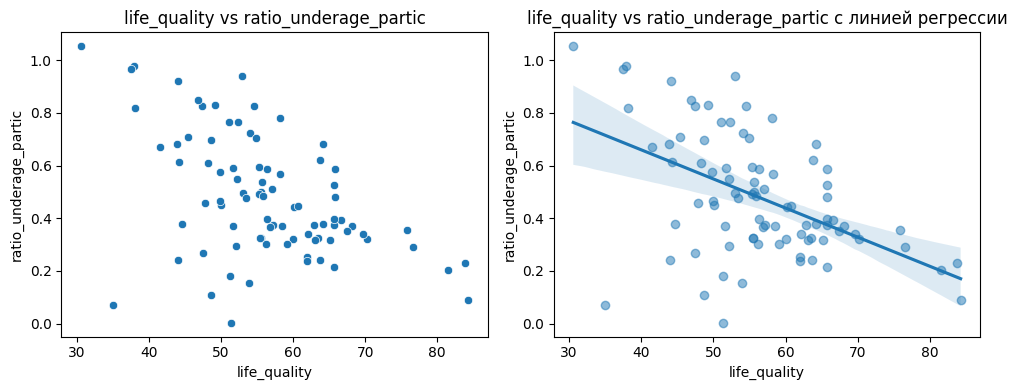

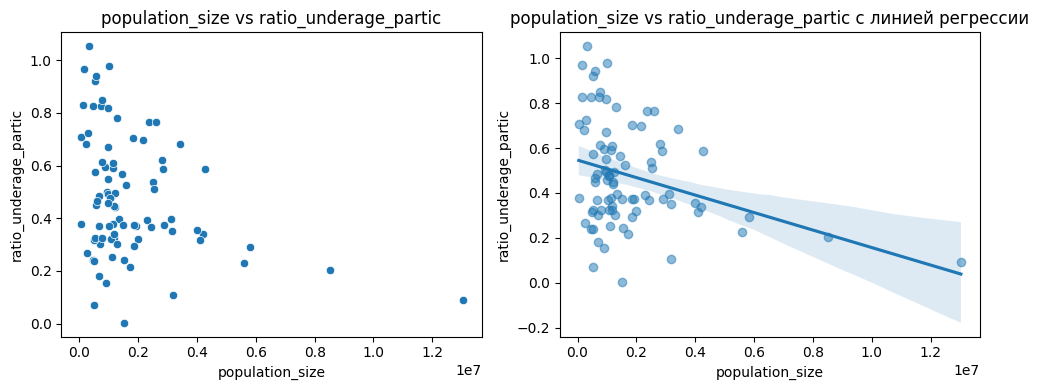

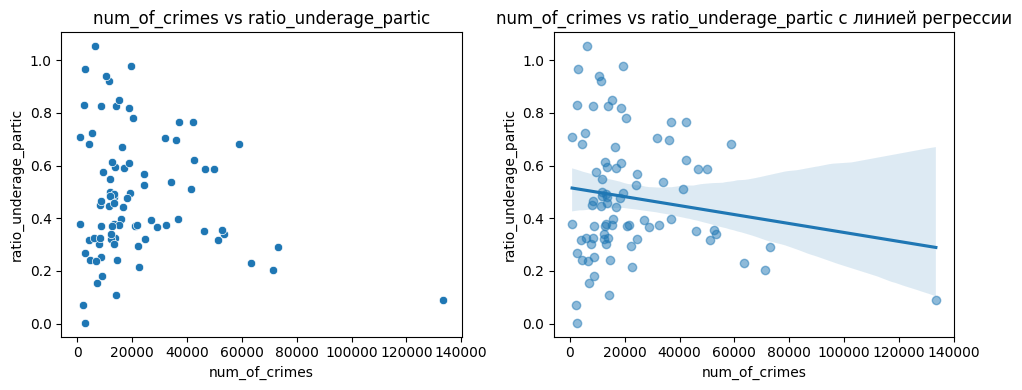

In [27]:
for col in df.columns[1:]:
    if col != 'ratio_underage_partic':
        plt.figure(figsize=(10, 4))
        # Scatter plot
        plt.subplot(1, 2, 1)
        sns.scatterplot(x=df[col], y=df['ratio_underage_partic'])
        plt.title(f'{col} vs ratio_underage_partic')
        # Jointplot с регрессией
        plt.subplot(1, 2, 2)
        sns.regplot(x=df[col], y=df['ratio_underage_partic'], scatter_kws={'alpha':0.5})
        plt.title(f'{col} vs ratio_underage_partic с линией регрессии')
        plt.tight_layout()
        plt.show()

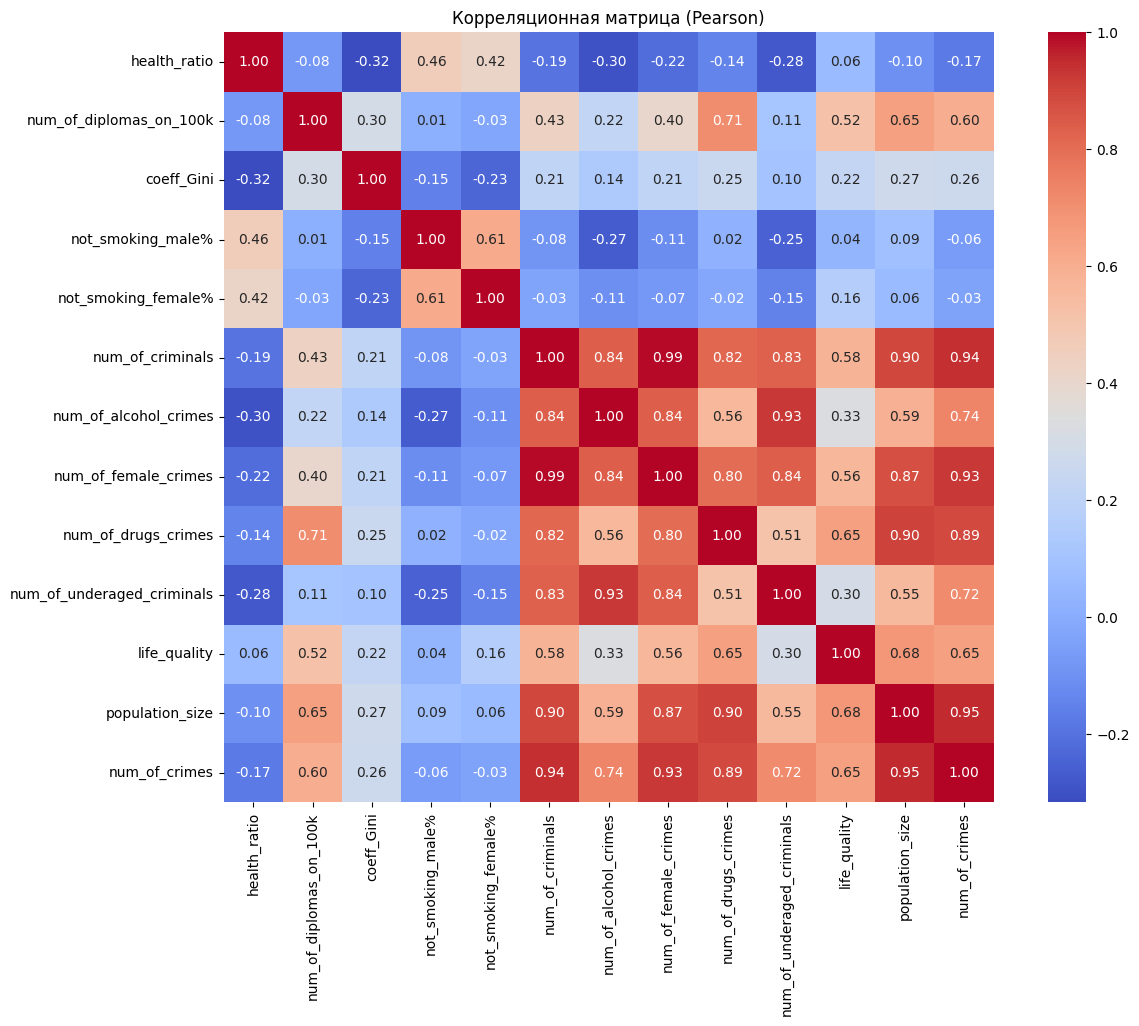

In [31]:
plt.figure(figsize=(14,10))
corr = df.drop(['region'], axis=1).corr(method='pearson')  # или spearman
sns.heatmap(corr.drop('ratio_underage_partic').drop('ratio_underage_partic', axis=1), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица (Pearson)')
plt.show()

In [36]:
corr_with_target = corr[['ratio_underage_partic']]
corr_with_target.sort_values('ratio_underage_partic', key=abs, ascending=False)

,ratio_underage_partic
ratio_underage_partic,1.000000
not_smoking_female%,-0.668180
not_smoking_male%,-0.590750
life_quality,-0.498044
health_ratio,-0.378314
population_size,-0.320114
num_of_underaged_criminals,0.261399
num_of_drugs_crimes,-0.214892
num_of_diplomas_on_100k,-0.194213
num_of_alcohol_crimes,0.164779


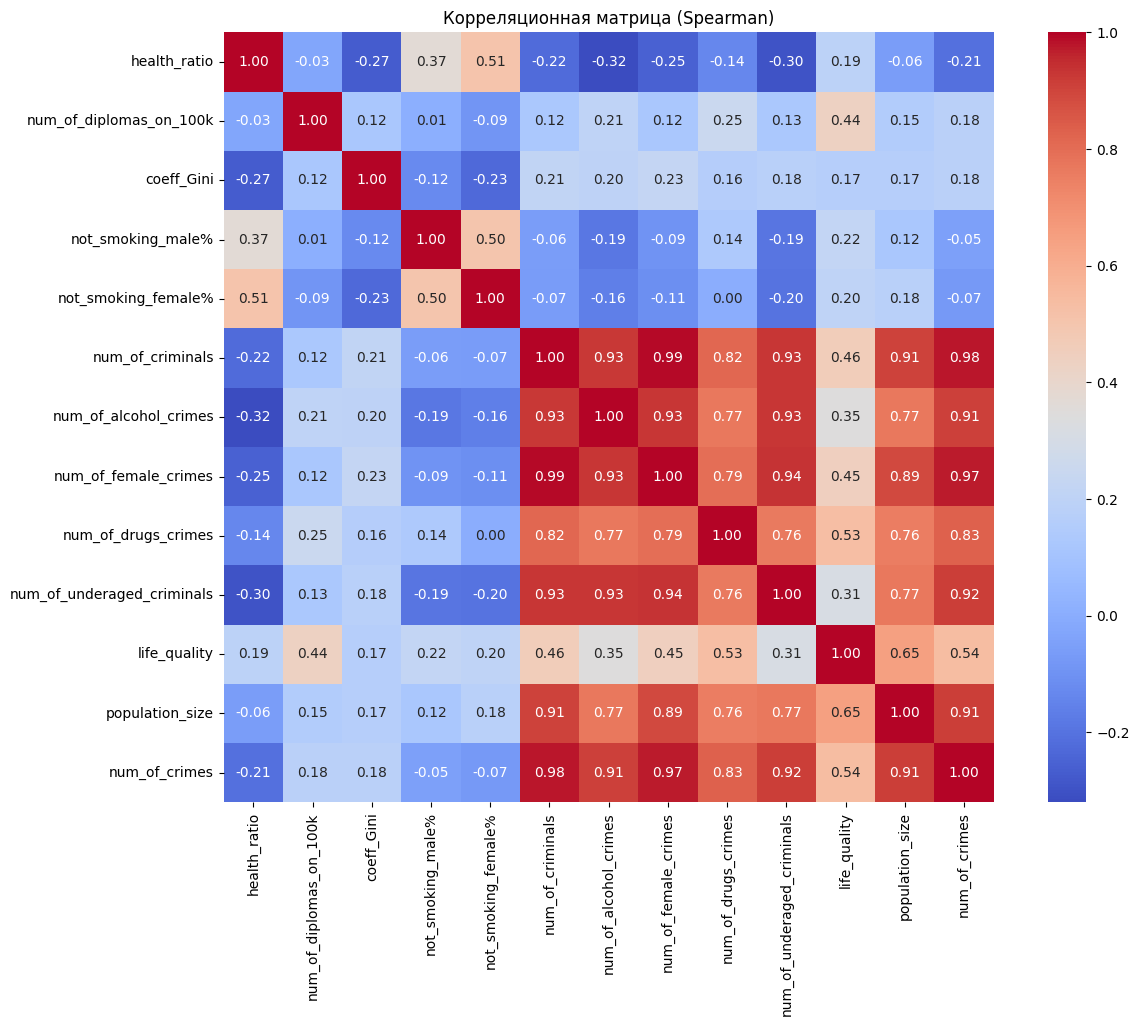

In [37]:
plt.figure(figsize=(14,10))
corr = df.drop(['region'], axis=1).corr(method='spearman')
sns.heatmap(corr.drop('ratio_underage_partic').drop('ratio_underage_partic', axis=1), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица (Spearman)')
plt.show()

In [38]:
corr_with_target = corr[['ratio_underage_partic']]
corr_with_target.sort_values('ratio_underage_partic', key=abs, ascending=False)

,ratio_underage_partic
ratio_underage_partic,1.000000
not_smoking_female%,-0.639655
not_smoking_male%,-0.603159
health_ratio,-0.449605
life_quality,-0.446993
num_of_underaged_criminals,0.318316
population_size,-0.254086
num_of_alcohol_crimes,0.218714
num_of_drugs_crimes,-0.062559
num_of_female_crimes,0.061736
